# 1. Fundamento Físico

El rendering moderno se basa en la conservación de la energía luminosa.

Cuando la luz incide sobre una superficie, puede:

- Reflejarse
- Absorberse
- Transmitirse

La ecuación que modela este fenómeno fue propuesta por James Kajiya en 1986 y se conoce como la **Ecuación de Renderizado**.



N=10, Estimación=1.9206850992807498, Error=0.34988877248585326
N=100, Estimación=1.4350770239356672, Error=0.1357193028592294
N=1000, Estimación=1.6064458879237122, Error=0.03564956112881568
N=10000, Estimación=1.5735701084844007, Error=0.002773781689504151


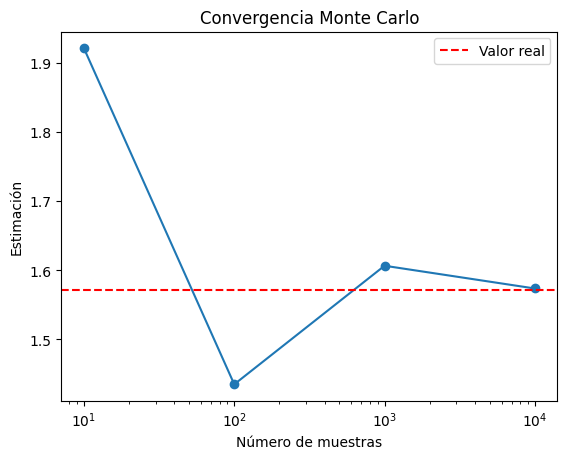

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Número de muestras
N_values = [10, 100, 1000, 10000]

def monte_carlo_cosine(N):
    # Muestreo uniforme en el hemisferio
    theta = np.arccos(np.random.rand(N))
    phi = 2 * np.pi * np.random.rand(N)

    # Componente coseno
    cos_theta = np.cos(theta)

    # Estimador Monte Carlo
    return np.pi * np.mean(cos_theta)

real_value = np.pi / 2  # Valor real de la integral

results = []

for N in N_values:
    estimate = monte_carlo_cosine(N)
    results.append(estimate)
    print(f"N={N}, Estimación={estimate}, Error={abs(estimate-real_value)}")

# Visualización
plt.plot(N_values, results, marker='o')
plt.axhline(real_value, color='r', linestyle='--', label="Valor real")
plt.xscale("log")
plt.xlabel("Número de muestras")
plt.ylabel("Estimación")
plt.legend()
plt.title("Convergencia Monte Carlo")
plt.show()

# 2. Ecuación de Renderizado

La ecuación integral es:

$$
L_o(x, \omega_o) =
L_e(x, \omega_o) +
\int_{\Omega}
f_r(x,\omega_i,\omega_o)
L_i(x,\omega_i)
(\omega_i \cdot n)
d\omega_i
$$

Donde:

- $L_o$ = Radiancia saliente
- $L_e$ = Radiancia emitida
- $L_i$ = Radiancia incidente
- $f_r$ = BRDF (modelo de reflexión)
- $(\omega_i \cdot n)$ = Factor geométrico (coseno)
- $\Omega$ = Hemisferio sobre la superficie

# 3. Problema Matemático

La ecuación de renderizado es:

- Una ecuación integral
- Recursiva
- Sin solución analítica en escenas reales

Por lo tanto, debemos aproximarla numéricamente.

El problema central es calcular la integral:

$$
\int_{\Omega} f(\omega) \, d\omega
$$


In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Intersección rayo-esfera
def intersect_sphere(ray_origin, ray_dir, sphere_center, radius):
    oc = ray_origin - sphere_center
    a = np.dot(ray_dir, ray_dir)
    b = 2.0 * np.dot(oc, ray_dir)
    c = np.dot(oc, oc) - radius * radius
    discriminant = b*b - 4*a*c

    if discriminant < 0:
        return None

    t = (-b - np.sqrt(discriminant)) / (2.0 * a)
    if t > 0:
        return t
    return None


# Muestreo uniforme en hemisferio
def random_hemisphere(normal):
    z = np.random.rand()
    r = np.sqrt(1 - z*z)
    phi = 2 * np.pi * np.random.rand()

    x = r * np.cos(phi)
    y = r * np.sin(phi)

    sample = np.array([x, y, z])

    # Alinear con normal
    if np.dot(sample, normal) < 0:
        sample = -sample

    return sample

# 4. Método de Monte Carlo

Monte Carlo aproxima integrales mediante muestreo aleatorio.

Si queremos calcular:

$$
I = \int f(x) dx
$$

Se aproxima como:

$$
I \approx \frac{1}{N} \sum_{i=1}^{N} \frac{f(x_i)}{p(x_i)}
$$

Donde:

- $x_i$ son muestras aleatorias
- $p(x)$ es la función de probabilidad
- $N$ es el número de muestras

El error disminuye como:

$$
Error \sim \frac{1}{\sqrt{N}}
$$

In [5]:
def render(samples_per_pixel):
    width, height = 100, 100
    image = np.zeros((height, width))

    sphere_center = np.array([0, 0, -3])
    radius = 1
    camera = np.array([0, 0, 0])

    for i in range(height):
        for j in range(width):

            color = 0

            for s in range(samples_per_pixel):

                # Coordenadas normalizadas
                x = (j / width - 0.5) * 2
                y = (i / height - 0.5) * 2

                ray_dir = np.array([x, y, -1])
                ray_dir = ray_dir / np.linalg.norm(ray_dir)

                t = intersect_sphere(camera, ray_dir, sphere_center, radius)

                if t is not None:
                    hit_point = camera + t * ray_dir
                    normal = (hit_point - sphere_center)
                    normal = normal / np.linalg.norm(normal)

                    # Monte Carlo hemisférico
                    light = 0
                    sample_dir = random_hemisphere(normal)
                    light = max(np.dot(sample_dir, normal), 0)

                    color += light

            image[i, j] = color / samples_per_pixel

    return image

Render sin Monte Carlo (1 sample)...


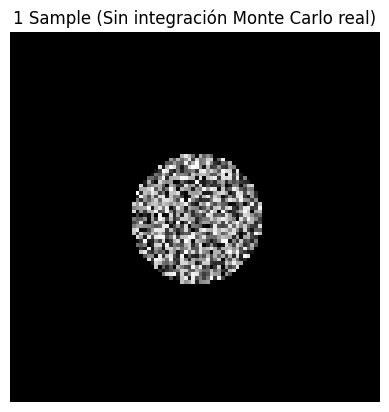

In [9]:
print("Render sin Monte Carlo (1 sample)...")
img_1 = render(1)

plt.imshow(img_1, cmap='gray')
plt.title("1 Sample (Sin integración Monte Carlo real)")
plt.axis("off")
plt.show()

Render con Monte Carlo (100 samples)...


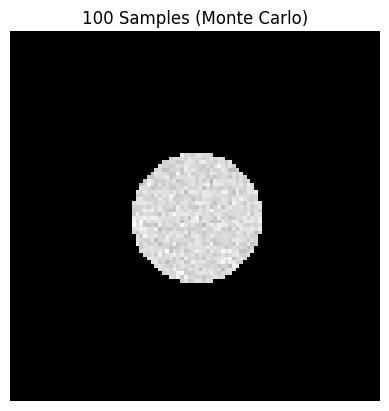

In [12]:
print("Render con Monte Carlo (100 samples)...")
img_100 = render(100)

plt.imshow(img_100, cmap='gray')
plt.title("100 Samples (Monte Carlo)")
plt.axis("off")
plt.show()

Render con Monte Carlo (1000 samples)...


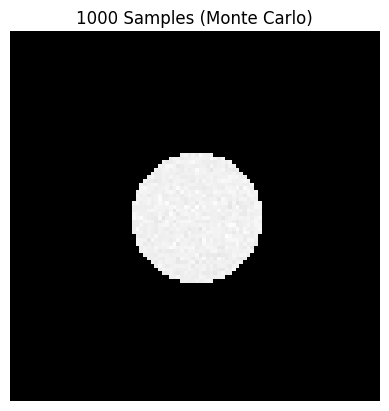

In [14]:
print("Render con Monte Carlo (1000 samples)...")
img_100 = render(1000)

plt.imshow(img_100, cmap='gray')
plt.title("1000 Samples (Monte Carlo)")
plt.axis("off")
plt.show()

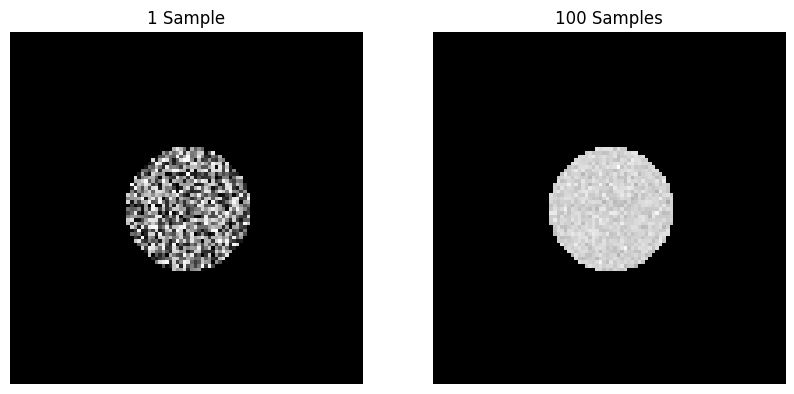

In [10]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_1, cmap='gray')
plt.title("1 Sample")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_100, cmap='gray')
plt.title("100 Samples")
plt.axis("off")

plt.show()

# 8. Relación con Path Tracing

El Path Tracing utiliza Monte Carlo para:

- Simular rebotes de luz
- Aproximar la ecuación de renderizado
- Resolver integrales en múltiples dimensiones

Cada píxel es el promedio de muchas trayectorias aleatorias.

Más trayectorias → menor varianza → mayor realismo.

# 9. Conclusión

La ecuación de renderizado es una ecuación integral sin solución cerrada.

Monte Carlo permite aproximarla mediante:

- Muestreo aleatorio
- Promedio estadístico
- Convergencia probabilística

Este principio es la base matemática y física del rendering moderno.